In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

## Get player details


In [3]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home'], axis=1)
player_cols = players_preds.columns.tolist()


In [4]:
gw=35
data_22_23 = pd.read_csv('../FPL predictors/with new features/data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('../FPL predictors/with new features/data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_cols = player_cols.copy()
data_cols.pop(data_cols.index('xP_preds'))
data_cols.pop(data_cols.index('player_team'))


data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

In [5]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

X_gk = scaler_gk.fit_transform(gk_data)
X_def = scaler_def.fit_transform(def_data)
X_mid = scaler_mid.fit_transform(mid_data)
X_fwd = scaler_fwd.fit_transform(fwd_data)


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

# # 4. Check variance explained
# print("Explained variance ratio per PC:", pca_gk.explained_variance_ratio_)
# print("Cumulative explained variance:", np.cumsum(pca_gk.explained_variance_ratio_))


Original shape: (501, 236) (2387, 236) (3823, 236) (863, 236)
Reduced shape: (501, 65) (2387, 69) (3823, 69) (863, 65)


In [6]:
data_ = players_preds[data_cols]
gk_data_tar = players_preds[players_preds['position'] == 'GK'][gk_data.columns]
def_data_tar = players_preds[players_preds['position'] == 'DEF'][def_data.columns]
mid_data_tar = players_preds[players_preds['position'] == 'MID'][mid_data.columns]
fwd_data_tar = players_preds[players_preds['position'] == 'FWD'][fwd_data.columns]


gk_data_tar = gk_data_tar.select_dtypes(include=[np.number])
gk_data_tar = pd.DataFrame(minmax_scale(gk_data_tar), columns=gk_data_tar.columns, index=gk_data_tar.index)

def_data_tar = def_data_tar.select_dtypes(include=[np.number])
# Data
def_data_tar = pd.DataFrame(minmax_scale(def_data_tar), columns=def_data_tar.columns, index=def_data_tar.index)

mid_data_tar = mid_data_tar.select_dtypes(include=[np.number])
mid_data_tar = pd.DataFrame(minmax_scale(mid_data_tar), columns=mid_data_tar.columns, index=mid_data_tar.index)

fwd_data_tar = fwd_data_tar.select_dtypes(include=[np.number])
fwd_data_tar = pd.DataFrame(minmax_scale(fwd_data_tar), columns=fwd_data_tar.columns, index=fwd_data_tar.index)

# Make sure there are no nan or inf
def clean_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    return arr

gk_data_tar  = clean_array(gk_data_tar)
def_data_tar = clean_array(def_data_tar)
mid_data_tar = clean_array(mid_data_tar)
fwd_data_tar = clean_array(fwd_data_tar)


In [7]:
X_gk_tar = scaler_gk.transform(gk_data_tar)
X_def_tar = scaler_def.transform(def_data_tar)
X_mid_tar = scaler_mid.transform(mid_data_tar)
X_fwd_tar = scaler_fwd.transform(fwd_data_tar)


# 3. Fit PCA and transform
X_gk_pca_tar = pd.DataFrame(pca_gk.transform(X_gk_tar))
X_def_pca_tar = pd.DataFrame(pca_def.transform(X_def_tar))
X_mid_pca_tar = pd.DataFrame(pca_mid.transform(X_mid_tar))
X_fwd_pca_tar = pd.DataFrame(pca_fwd.transform(X_fwd_tar))

print("Original shape:", X_gk_tar.shape, X_def_tar.shape, X_mid_tar.shape, X_fwd_tar.shape)
print("Reduced shape:", X_gk_pca_tar.shape, X_def_pca_tar.shape, X_mid_pca_tar.shape, X_fwd_pca_tar.shape)

# # 4. Check variance explained
# print("Explained variance ratio per PC:", pca_gk.explained_variance_ratio_)
# print("Cumulative explained variance:", np.cumsum(pca_gk.explained_variance_ratio_))

Original shape: (17, 236) (93, 236) (136, 236) (28, 236)
Reduced shape: (17, 65) (93, 69) (136, 69) (28, 65)


c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Wo Component


In [8]:
def get_beta(data):
    # Ensure data is numeric
    data = data.select_dtypes(include=[np.number])  # Drop non-numeric columns

    # Shape parameters
    np.random.seed(42)
    num_players, num_features = data.shape

    print(f"Number of Players: {num_players}, Features: {num_features}")

    # Convert to NumPy with float type
    X = data.to_numpy(dtype=np.float64)
    X = X.reshape((num_players, num_features))
    print(X.shape)

    # Observed probability distribution (Ensure valid probabilities)
    p = np.abs(np.random.randn(num_players, ))
    p /= p.sum( keepdims=True)  # Normalize to sum to 1
    print("p shape:", p.shape)

    with pm.Model() as model:
        # Prior: Uniform distribution for β
        beta = pm.Uniform("beta", lower=-1, upper=1, shape=(num_features,))
        print("Beta shape:", beta.shape)

        # Compute α = exp(X β) and ensure correct shape
        epsilon = 1e-3
        alpha = pm.math.exp(pm.math.dot(X, beta)) + epsilon
        print("Alpha shape:", alpha.shape)

        # Dirichlet likelihood (Ensure shape matches p)
        p = pm.Dirichlet("p", a=alpha, observed=p)
        # Debugging step to check the model
        model.debug(verbose=True)
        # MCMC Sampling
        trace = pm.sample(2000, return_inferencedata=True, target_accept=0.9)

    # Get estimated β values
    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"])
    print("Estimated β values:", beta_estimated.values)
    return beta_estimated

### Get betas


In [9]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

simulate_observed_probs(gk_data)

23       0.001270
24       0.000815
25       0.001514
26       0.001125
27       0.004494
           ...   
11071    0.000870
11072    0.000464
11073    0.001270
11074    0.001883
11075    0.001015
Length: 501, dtype: float64

In [77]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=2000,
            # tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [78]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()
# X_data_gk = X_data_gk.fillna(0)
# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_data_gk)
# eta_gk = get_beta(gk_data)

Number of Players: 501, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2078 seconds.
There were 42 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.2050674   0.32983705 -0.0387145   0.0198591   0.02404252  0.06935005
 -0.02990137 -0.0544526   0.00959138 -0.08525759  0.08757231  0.07969568
  0.09977604 -0.08013768 -0.19630807 -0.08423107  0.13130511 -0.21686134
 -0.16438433  0.06165794 -0.00162426  0.00618925 -0.01937473 -0.06455277
 -0.0659248  -0.12725173 -0.10304876  0.16143365 -0.06284254 -0.08087934
  0.17019297 -0.10157124  0.19650729  0.16963876  0.09678642 -0.07747026
  0.12234547 -0.02050786 -0.01986473 -0.05656658 -0.07097342  0.01978997
 -0.19016575  0.14189337  0.00684872  0.2415981   0.02045349 -0.02303986
  0.00253217 -0.3476853   0.07045745 -0.10382445  0.23917321 -0.01634233
 -0.08926775 -0.03350653  0.21662791 -0.04404594 -0.10206409 -0.03337602
  0.12098096 -0.12283091 -0.0712733   0.01628798 -0.01059663]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

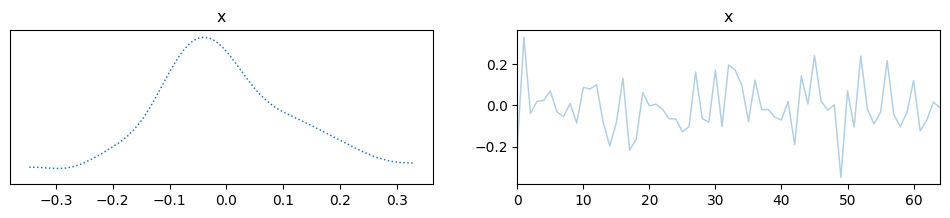

In [79]:
az.plot_trace(beta_gk, combined=True)


In [80]:
az.plot_pair(beta_gk, kind='kde', divergences=True)
plt.show()

c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\plots\pairplot.py:223: UserWarning: Divergences data not found, plotting without divergences. Make sure the sample method provides divergences data and that it is present in the `diverging` field of `sample_stats` or `sample_stats_prior` or set divergences=False
  warnings.warn(


ValueError: Number of variables to be plotted must be 2 or greater.

In [12]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2387, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 5509 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.24946716  0.36231664  0.14141718  0.02913216 -0.44807817  0.04219126
  0.06932204  0.42668716  0.37965626  0.17164556 -0.55529737  0.39077974
  0.1736344  -0.4311034  -0.48256581  0.16703715  0.27115076 -0.00726396
 -0.19208666 -0.25490288  0.06845381 -0.01118131  0.11038019 -0.28981033
  0.05927851  0.45765676 -0.34802225  0.1277671  -0.35422814 -0.06780819
  0.27549613 -0.37813257 -0.4600176   0.5901332   0.41588747  0.0860747
 -0.41430445 -0.18641734  0.07185376  0.13960603 -0.3176175   0.05862907
 -0.34271533  0.24455054  0.33809658  0.53500779  0.04576219 -0.43048847
 -0.31929327 -0.55239299 -0.22285424 -0.34247517  0.47787959  0.42285875
  0.22355557  0.62500506 -0.20763267 -0.57139435  0.16284098  0.10683332
 -0.02601349  0.07942302  0.23067231 -0.55775711  0.1537745   0.44022988
 -0.27289298  0.44590306 -0.69835508]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

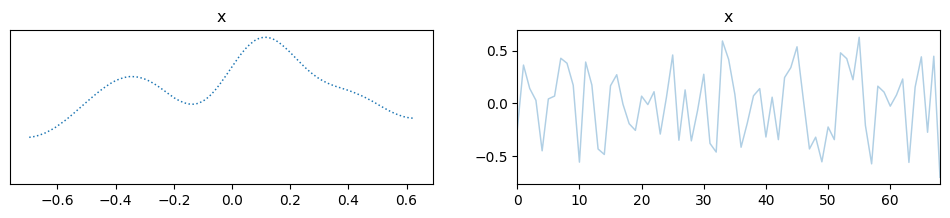

In [ ]:
az.plot_trace(beta_def, combined=True)

In [13]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 3823, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 173 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.26372631 -0.05064554  0.10543003  0.22575024 -0.33204975  0.08504362
 -0.32932018 -0.5213496   0.74367777  0.20043044  0.03877585 -0.14512743
 -0.34536408  0.55385327  0.06500477 -0.24894755  0.11700122  0.38451719
  0.47105923 -0.44976109 -0.02264714 -0.39871668 -0.28365773  0.1014075
  0.23704018  0.18670749  0.22512288  0.5051443  -0.08798722 -0.35979448
 -0.66929557 -0.27155641 -0.35609687 -0.37353045  0.55027555 -0.57860614
 -0.21901726 -0.44224264  0.29244576 -0.13968192  0.06550262  0.89934321
  0.35854999  0.11245782 -0.22516769 -0.29344899  0.28841176 -0.1219105
  0.011553    0.2510249   0.67512551  0.12911477 -0.51884135  0.13070468
 -0.7690819   0.19730219  0.02307349 -0.55906365 -0.66620705 -0.66175849
  0.67026116 -0.31360756 -0.42080784  0.38806971  0.24412343 -0.03797025
 -0.3270467  -0.00920896  0.12972529]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

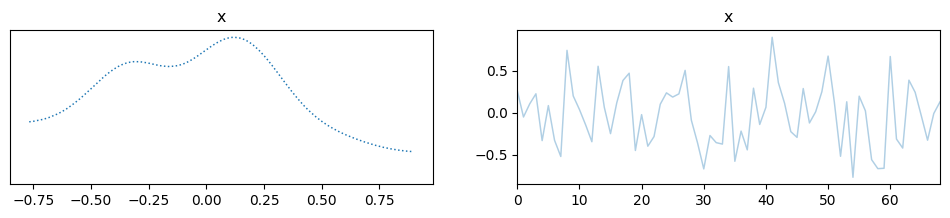

In [60]:
az.plot_trace(beta_mid, combined=True)

In [14]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 863, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 1433 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.1116052   0.26783472 -0.00988609  0.01934264 -0.08125932 -0.10761174
 -0.28765761  0.12058405  0.08194963  0.12047888 -0.30146664  0.22090688
  0.02683778 -0.01860854 -0.05210445 -0.10519313  0.0559456  -0.12059748
  0.16802286 -0.04205376  0.18025985 -0.2502558  -0.12971329  0.28041232
  0.06197112  0.02574536 -0.1969978   0.21144893 -0.11720902  0.0805786
 -0.14622919 -0.19600107 -0.11246357  0.13714279  0.43947576  0.42901848
  0.02146361 -0.42079065  0.04850143 -0.22597925  0.28620587  0.40676383
 -0.33407019  0.08222952  0.10894108 -0.13759622 -0.37788256 -0.16058333
  0.29362999 -0.12323658  0.21641515  0.00561864  0.13428675  0.5022235
 -0.16103063  0.39243998 -0.11232713  0.00572062 -0.62940321 -0.49343778
 -0.03912756 -0.43782306  0.45339163  0.13465626 -0.00340692]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

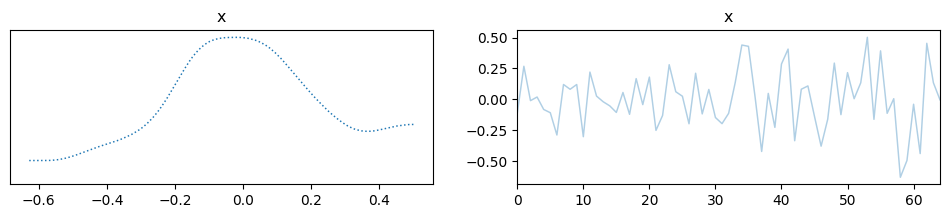

In [61]:
az.plot_trace(beta_fwd, combined=True)

In [15]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)

### Use the betas


In [16]:
beta_gk_ = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def_ = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid_ = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd_ = pd.read_csv('./fwd_beta.csv').values.squeeze()

alpha_gk_pred = np.exp(np.dot(X_gk_pca_tar, beta_gk_.T))
alpha_def_pred = np.exp(np.dot(X_def_pca_tar, beta_def_.T))
alpha_mid_pred = np.exp(np.dot(X_mid_pca_tar, beta_mid_.T))
alpha_fwd_pred = np.exp(np.dot(X_fwd_pca_tar, beta_fwd_.T))

In [17]:
dir_gk = np.random.dirichlet(alpha_gk_pred).tolist()
dir_def = np.random.dirichlet(alpha_def_pred).tolist()
dir_mid = np.random.dirichlet(alpha_mid_pred).tolist()
dir_fwd = np.random.dirichlet(alpha_fwd_pred).tolist()

In [18]:
f = len(beta_gk_)  # Number of group

# Step 2: Define and sample from Dirichlet distribution
with pm.Model() as model:
    p_gk = pm.Dirichlet("p_gk", a=alpha_gk_pred)  # Ensure correct shape
    p_def = pm.Dirichlet("p_def", a=alpha_def_pred)  # Ensure correct shape
    p_mid = pm.Dirichlet("p_mid", a=alpha_mid_pred)  # Ensure correct shape
    p_fwd = pm.Dirichlet("p_fwd", a=alpha_fwd_pred)  # Ensure correct shape

    trace = pm.sample_prior_predictive(samples=1)

Sampling: [p_def, p_fwd, p_gk, p_mid]


In [19]:
# Extract samples correctly
sampled_p_gk = trace.prior["p_gk"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_def = trace.prior["p_def"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_mid = trace.prior["p_mid"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_fwd = trace.prior["p_fwd"].values.squeeze()  # Ensure shape is (f, num_features)"


In [20]:
W = set()  # Placeholder for valid portfolios
Wo = []  # List to store accepted portfolios

In [21]:
# # Ensure sampled probabilities are valid
# sampled_p_gk = np.nan_to_num(sampled_p_gk, nan=1.0 / len(sampled_p_gk))
# sampled_p_def = np.nan_to_num(sampled_p_def, nan=1.0 / len(sampled_p_def))
# sampled_p_mid = np.nan_to_num(sampled_p_mid, nan=1.0 / len(sampled_p_mid))
# sampled_p_fwd = np.nan_to_num(sampled_p_fwd, nan=1.0 / len(sampled_p_fwd))

# # Normalize probabilities to ensure they sum to 1
# sampled_p_gk /= sampled_p_gk.sum()
# sampled_p_def /= sampled_p_def.sum()
# sampled_p_mid /= sampled_p_mid.sum()
# sampled_p_fwd /= sampled_p_fwd.sum()

# # Generate random samples
# gk = np.random.multinomial(1, sampled_p_gk)
# def_ = np.random.multinomial(3, sampled_p_def)
# mid = np.random.multinomial(4, sampled_p_mid)
# fwd = np.random.multinomial(4, sampled_p_fwd)

# # Extract indices of selected players
# gk_idx = [i for i, x in enumerate(gk) if x == 1]
# def_idx = [i for i, x in enumerate(def_) if x == 1]
# mid_idx = [i for i, x in enumerate(mid) if x == 1]
# fwd_idx = [i for i, x in enumerate(fwd) if x == 1]

# gk_idx, def_idx, mid_idx, fwd_idx

In [22]:
# # Manually compute alpha values and check ranges
# epsilon = 1e-3
# alpha_g = np.exp(np.dot(X_gk_pca_tar, beta_gk_.T)) #+ epsilon
# alpha_d = np.exp(np.dot(X_def_pca_tar, beta_def_.T)) #+ epsilon
# alpha_m = np.exp(np.dot(X_mid_pca_tar, beta_mid_.T)) #+ epsilon
# alpha_f = np.exp(np.dot(X_fwd_pca_tar, beta_fwd_.T)) #+ epsilon

# print("Alpha gk: min", alpha_g.min(), " max", alpha_g.max())
# print("Alpha def: min", alpha_d.min(), " max", alpha_d.max())
# print("Alpha mid: min", alpha_m.min(), " max", alpha_m.max())
# print("Alpha fwd: min", alpha_f.min(), " max", alpha_f.max())


In [23]:
# === Step 1: Define Constants ===
P = 100  # Total available players
C = 15  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget
O = 1000  # Number of squad simulations

# Example positions: Assume these are valid players for selection
Pg, Pd, Pm, Pf = len(gk_data_tar), len(def_data_tar), len(mid_data_tar), len(fwd_data_tar)  # Players per position
positions = {"g": Pg, "d": Pd, "m": Pm, "f": Pf}

# === Step 2: Generate Dirichlet Parameters for Position Selection ===
epsilon = 1e-3  # Small constant to avoid numerical issues

def safe_alpha(X_pca, beta):
    raw_scores = pm.math.dot(X_pca, beta.T)
    raw_scores -= pm.math.max(raw_scores)
    alpha = pm.math.exp(raw_scores) + epsilon
    alpha = pm.math.clip(alpha, 1e-3, 1e3)
    return alpha

alpha_g = safe_alpha(X_gk_pca_tar, beta_gk_)
alpha_d = safe_alpha(X_def_pca_tar, beta_def_)
alpha_m = safe_alpha(X_mid_pca_tar, beta_mid_)
alpha_f = safe_alpha(X_fwd_pca_tar, beta_fwd_)

with pm.Model():
    pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
    pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
    pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
    pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

    trace = pm.sample(
            draws=1000,
            tune=500,
            target_accept=0.95,
            chains=4,
            cores=2,
            return_inferencedata=True,
            progressbar=True)

# Extract posterior means
pgk, pdef, pmid, pfwd = (
    trace.posterior["pg"].mean(dim=("chain", "draw")).values,
    trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
    trace.posterior["pm"].mean(dim=("chain", "draw")).values,
    trace.posterior["pf"].mean(dim=("chain", "draw")).values,)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 524 seconds.
There were 3992 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:249: RuntimeWarning: divide by zero encountered in scalar power
  out = t - (2 * N * np.pi**0.5 * f) ** (-0.4)
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:699: RuntimeWarning: overflow encountered in divide
  f = grid_counts / bin_width / len(x)
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:720: RuntimeWarning: invalid value encountered in divide
  pdf /= bw * (2 * np.pi) ** 0.5


array([[<Axes: title={'center': 'pg'}>, <Axes: title={'center': 'pg'}>],
       [<Axes: title={'center': 'pd_'}>, <Axes: title={'center': 'pd_'}>],
       [<Axes: title={'center': 'pm'}>, <Axes: title={'center': 'pm'}>],
       [<Axes: title={'center': 'pf'}>, <Axes: title={'center': 'pf'}>]],
      dtype=object)

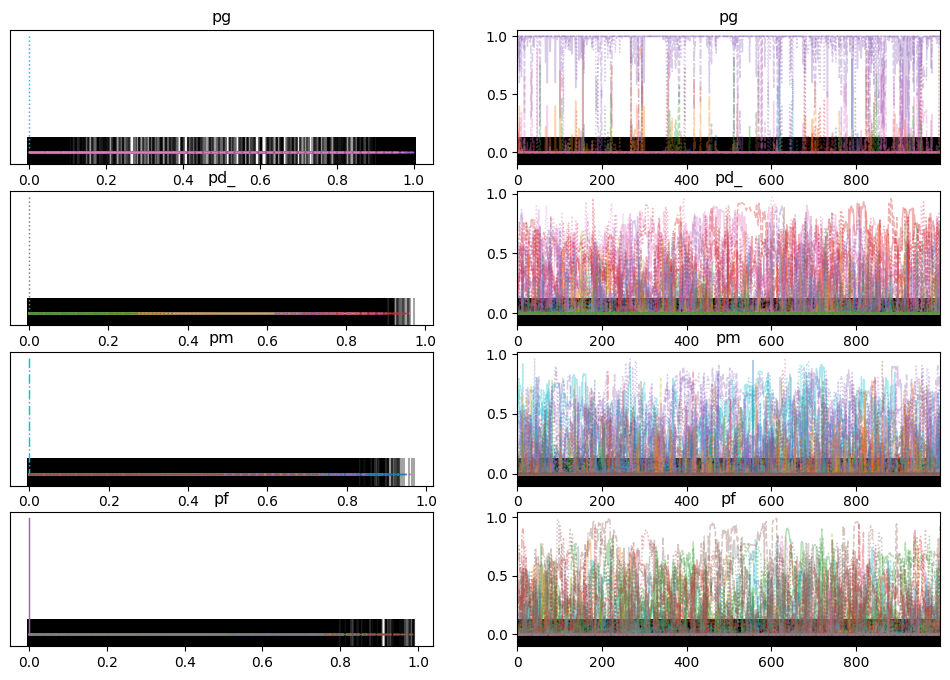

In [24]:

az.plot_trace(data=trace, var_names=["pg", "pd_", 'pm', 'pf'])

In [25]:
pg_ = pd.DataFrame({'gk': pgk})
pd_ = pd.DataFrame({'def': pdef})
pmid_ = pd.DataFrame({'mid': pmid})
pf_ = pd.DataFrame({'fwd': pfwd})

pg_.to_csv('./gk_beta_post.csv', index=False)
pd_.to_csv('./def_beta_post.csv', index=False)
pmid_.to_csv('./mid_beta_post.csv', index=False)
pf_.to_csv('./fwd_beta_post.csv', index=False)

### Generate Wo


In [14]:
d_prices.values.flatten().tolist()

[3.9,
 4.4,
 4.4,
 4.3,
 5.8,
 4.2,
 3.9,
 4.6,
 4.3,
 3.8,
 6.1,
 4.0,
 4.5,
 3.8,
 4.4,
 4.7,
 4.0,
 4.5,
 5.2,
 4.5,
 4.4,
 4.3,
 4.4,
 5.6,
 4.9,
 4.5,
 5.3,
 4.4,
 4.0,
 3.8,
 4.8,
 3.9,
 4.1,
 4.0,
 4.5,
 4.8,
 4.2,
 4.2,
 6.4,
 4.3,
 4.4,
 4.3,
 3.9,
 4.3,
 4.4,
 4.4,
 4.9,
 3.9,
 4.9,
 5.3,
 4.7,
 4.6,
 4.3,
 4.4,
 4.3,
 4.5,
 3.8,
 5.3,
 4.6,
 4.5,
 5.2,
 4.2,
 4.5,
 5.2,
 4.8,
 4.2,
 5.3,
 4.9,
 5.1,
 4.8,
 5.8,
 4.3,
 4.3,
 4.2,
 5.5,
 4.1,
 4.4,
 4.3,
 4.4,
 3.9,
 4.6,
 4.3,
 7.2,
 4.4,
 4.8,
 4.4,
 4.4,
 4.3,
 6.7,
 4.3,
 4.1,
 6.5,
 3.8]

In [15]:
import numpy as np

# Assuming d_prices and pdef are numpy arrays of the same length
# and are correctly aligned by player
correlation = np.corrcoef(d_prices.values.flatten().tolist(), pd_curr)[0, 1]

print(f"Correlation between defender prices and probabilities: {correlation:.4f}")

# A result like -0.7 would indicate a strong tendency for cheaper players
# to have higher probabilities.

Correlation between defender prices and probabilities: -0.1087


In [4]:
pg_curr = pd.read_csv('./gk_beta_post.csv').values.squeeze()
pd_curr = pd.read_csv('./def_beta_post.csv').values.squeeze()
pm_curr = pd.read_csv('./mid_beta_post.csv').values.squeeze()
pf_curr = pd.read_csv('./fwd_beta_post.csv').values.squeeze()

players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

g_prices = players_preds[players_preds['position'] == 'GK'][['value']] #*10
d_prices = players_preds[players_preds['position'] == 'DEF'][['value']] #*10
m_prices = players_preds[players_preds['position'] == 'MID'][['value']] #*10
f_prices = players_preds[players_preds['position'] == 'FWD'][['value']] #*10

g_xPts = players_preds[players_preds['position'] == 'GK']['xP_preds'].tolist()
d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_preds'].tolist()
m_xPts = players_preds[players_preds['position'] == 'MID']['xP_preds'].tolist()
f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_preds'].tolist()

g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()

g_ids = players_preds[players_preds['position'] == "GK"]['FPL_ID'].tolist()
d_ids = players_preds[players_preds['position'] == "DEF"]['FPL_ID'].tolist()
m_ids = players_preds[players_preds['position'] == "MID"]['FPL_ID'].tolist()
f_ids = players_preds[players_preds['position'] == "FWD"]['FPL_ID'].tolist()


all_xPts = g_xPts + d_xPts + m_xPts + f_xPts

In [ ]:
from collections import Counter

# === Step 1: Define Constants ===
P = 100  # Total available players
C = 11  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget"

O = 50  # Number of squad simulations

O = 5000  # Number of squad simulations"

q = 0.25  # Assume 30% stacking probability

gk_sizes = [1]
def_sizes = [3,4,5]
mid_sizes = [2,3,4,5]
fwd_sizes = [1,2,3]
Wo = set()
# === Step 3: Generate Possible Team Selections (Algorithm 1) ===
def generate_squad(pg, pdef, pmid, pf, q, budget):

    """Generate a valid team selection for an opponent."""
    stack = np.random.binomial(1, q)  # Stacking decision


    # print('===============================> Adding Goalkeeper')
    while True:
        selected_g = np.random.multinomial(1, pg)
        if set(selected_g) <= {0, 1}:  # Ensure only 1s and 0s exist
            break
    g_cost = np.dot(selected_g, g_prices)[0]
    g_team_idx = [idx for idx, _ in enumerate(selected_g) if selected_g[idx] == 1]
    selected_team_g = [g_teams[i] for i in g_team_idx] # Get the selected teams
    squad_g = [g_ids[i] for i in g_team_idx]

    for i in def_sizes:
        # print('===============================> Adding Defender', i)
        while True: # substitute for a do_while loop
            while True:# Ensure only 1s and 0s exist
                selected_d = np.random.multinomial(i, pdef)
                if set(selected_d) <= {0, 1}:  # Ensure only 1s and 0s exist
                    break
            d_cost = np.dot(selected_d, d_prices)[0]
            d_team_idx = [idx for idx, _ in enumerate(selected_d) if selected_d[idx] == 1]
            selected_team_g_d = selected_team_g + [d_teams[i] for i in d_team_idx] # Get the selected teams
            squad_g_d = squad_g + [d_ids[i] for i in d_team_idx]

            if ((not any(team >=3 for team in Counter(selected_team_g_d).values())) and g_cost + d_cost < Blb):
                # Check if no more than 3 players from the same team are selected
                # If the cost is below the lower bound, break and continue to the next iteration
                break

        for j in mid_sizes:
            # print('===============================> Adding Midfielder ',i,  j)
            while True: # substitute for a do_while loop
                while True:
                    selected_m = np.random.multinomial(j, pmid)
                    if set(selected_m) <= {0, 1}:  # Ensure only 1s anm0s exist
                        break
                m_cost = np.dot(selected_m, m_prices)[0]
                m_team_idx = [idx for idx, _ in enumerate(selected_m) if selected_m[idx] == 1]
                selected_team_g_d_m = selected_team_g_d + [m_teams[i] for i in m_team_idx] # Get the selected teams
                squad_g_d_m = squad_g_d + [m_ids[i] for i in m_team_idx]

                if  ((not any(team >=3 for team in Counter(selected_team_g_d_m).values())) and g_cost + d_cost + m_cost < Blb):
                    # Check if no more than 3 players from the same team are selected
                    # If the cost is below the lower bound, break and continue to the next iteration
                    break

            for k in fwd_sizes:
                # print('===============================> Adding Forward ',i,  j, k)
                if(i+j+k < 10 or i+j+k > 10):
                    continue

                while True:
                    while True:
                        selected_f = np.random.multinomial(k, pf)
                        if set(selected_f) <= {0, 1}:  # Ensure only 1s anm0s exist
                            break
                    f_cost = np.dot(selected_f, f_prices)[0]

                    f_team_idx = [idx for idx, _ in enumerate(selected_f) if selected_f[idx] == 1]
                    selected_team_g_d_m_f = selected_team_g_d_m + [f_teams[i] for i in f_team_idx] # Get the selected teams
                    squad_g_d_m_f = squad_g_d_m + [f_ids[i] for i in f_team_idx]

                    squad_cost = g_cost + d_cost + m_cost + f_cost
                    print(squad_cost)
                    # ADD THIS LINE to see every attempt
                    print(f"Attempting squad with cost: {squad_cost:.1f}")
                    if  ((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and  squad_cost < Blb): # 70 <

                    #if((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and g_cost + d_cost + m_cost + f_cost < Blb):

                        # Check if no more than 3 players from the same team are selected
                        # If the cost is below the lower bound, break and continue to the next iteration
                        Wo.add(tuple(squad_g_d_m_f))
                        break

squad = generate_squad(pg_curr, pd_curr, pm_curr, pf_curr, q, budget)
len(Wo)
# Generate O possible squads
while len(Wo)  < O:
    generate_squad(pg_curr, pd_curr, pm_curr, pf_curr, q, budget)
    print(f'-------------------------------> {len(Wo)} ===> {(len(Wo)/O)*100}%')
# Print example squad
print("Example Generated Squad:", len(Wo))

60.60000000000001
Attempting squad with cost: 60.6
63.2
Attempting squad with cost: 63.2
61.599999999999994
Attempting squad with cost: 61.6
69.5
Attempting squad with cost: 69.5
59.5
Attempting squad with cost: 59.5
69.1
Attempting squad with cost: 69.1
66.7
Attempting squad with cost: 66.7
67.1
Attempting squad with cost: 67.1
69.5
Attempting squad with cost: 69.5
60.199999999999996
Attempting squad with cost: 60.2
61.9
Attempting squad with cost: 61.9
58.199999999999996
Attempting squad with cost: 58.2
56.699999999999996
Attempting squad with cost: 56.7
61.2
Attempting squad with cost: 61.2
59.5
Attempting squad with cost: 59.5
68.6
Attempting squad with cost: 68.6
67.4
Attempting squad with cost: 67.4
67.4
Attempting squad with cost: 67.4
59.5
Attempting squad with cost: 59.5
58.0
Attempting squad with cost: 58.0
59.8
Attempting squad with cost: 59.8
66.3
Attempting squad with cost: 66.3
69.1
Attempting squad with cost: 69.1
67.1
Attempting squad with cost: 67.1
61.4
Attempting squ

In [ ]:

def generate_wo_with_knapsack(players, budget, formations, num_squads_to_generate):
    """
    Generates a set of high-quality, valid squads using a randomized
    greedy knapsack-style approach.

    Returns:
        A set of squads, where each squad is a frozenset of player IDs.
    """
    Wo = set()

    # Group players by position for quick lookups
    players_by_pos = collections.defaultdict(list)
    for p in players:
        players_by_pos[p.position].append(p)

    # Use tqdm for a progress bar while generating squads
    pbar = tqdm(total=num_squads_to_generate, desc="Generating Squads")

    # Keep trying to generate squads until we reach the desired number
    attempts = 0
    max_attempts = num_squads_to_generate * 20 # Stop if it's too hard to find new squads
    while len(Wo) < num_squads_to_generate and attempts < max_attempts:
        attempts += 1

        # --- Start building one squad ---
        squad = []
        current_cost = 0.0
        team_counts = collections.defaultdict(int)

        # 1. Pick a random formation
        num_def, num_mid, num_fwd = random.choice(formations)
        squad_template = [('GK', 1), ('DEF', num_def), ('MID', num_mid), ('FWD', num_fwd)]

        possible = True
        for position, num_to_pick in squad_template:
            # 2. Find all valid candidates for the current position
            candidates = []
            weights = []

            # A player is a candidate if they fit the budget and team constraints
            remaining_budget = budget - current_cost
            for p in players_by_pos[position]:
                # Basic checks
                if p in squad: continue
                if p.price > remaining_budget: continue
                if team_counts[p.team] >= 3: continue

                candidates.append(p)
                # Use fpts as the weight for random selection. Add 1 to avoid zero weights.
                weights.append(p.fpts + 1)

            # 3. If enough valid candidates exist, make a weighted random choice
            if len(candidates) >= num_to_pick:
                # random.choices allows picking multiple items based on weights
                chosen_players = random.choices(candidates, weights=weights, k=num_to_pick)

                # Update the squad state
                squad.extend(chosen_players)
                current_cost += sum(p.price for p in chosen_players)
                for p in chosen_players:
                    team_counts[p.team] += 1
            else:
                # If we can't fill the slots, this attempt has failed. Break and try again.
                possible = False
                break

        # --- End building one squad ---

        # 4. If a full squad was built, add it to Wo
        if possible and len(squad) == 11:
            # Use a frozenset of player IDs as the key for Wo to ensure uniqueness
            squad_ids = frozenset(p.id for p in squad)
            if squad_ids not in Wo:
                Wo.add(squad_ids)
                pbar.update(1) # Update progress bar

    pbar.close()
    if attempts >= max_attempts:
        print(f"Warning: Reached max attempts ({max_attempts}). Generated {len(Wo)} unique squads.")

    return Wo

generate_wo_with_knapsack(players, budget, formations, num_squads_to_generate)


In [28]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import collections
import random
import numpy as np
from tqdm import tqdm

Player = collections.namedtuple("Player", ['id', 'name', 'position', 'team', 'price', 'prob'])

def generate_wo_multinomial_constrained(players, budget, formations, num_squads_to_generate):
    """
    Generates a set of valid squads using a constrained multinomial
    sampling approach.
    """
    Wo = set()

    # Create a map of player ID to player object for easy lookup
    player_map = {p.id: p for p in players}

    # Group player IDs and their probabilities by position
    player_info_by_pos = collections.defaultdict(lambda: {'ids': [], 'probs': []})
    for p in players:
        player_info_by_pos[p.position]['ids'].append(p.id)
        player_info_by_pos[p.position]['probs'].append(p.prob)

    pbar = tqdm(total=num_squads_to_generate, desc="Generating Squads")

    attempts = 0
    max_attempts = num_squads_to_generate * 50 # Increase attempts if it's difficult

    while len(Wo) < num_squads_to_generate and attempts < max_attempts:
        attempts += 1

        squad_ids = []
        current_cost = 0.0
        team_counts = collections.defaultdict(int)

        num_def, num_mid, num_fwd = random.choice(formations)
        squad_template = [('GK', 1), ('DEF', num_def), ('MID', num_mid), ('FWD', num_fwd)]

        is_squad_possible = True
        for position, num_to_pick in squad_template:
            # 1. Filter candidates based on current squad state
            candidate_ids = []
            candidate_probs = []

            # Get all players for the current position
            all_pos_ids = player_info_by_pos[position]['ids']
            all_pos_probs = player_info_by_pos[position]['probs']

            for player_id, prob in zip(all_pos_ids, all_pos_probs):
                player = player_map[player_id]
                # Add player if not already in squad and plausible
                if player_id not in squad_ids and player.price <= (budget - current_cost):
                    candidate_ids.append(player_id)
                    candidate_probs.append(prob)

            if len(candidate_ids) < num_to_pick:
                is_squad_possible = False
                break

            # 2. Renormalize probabilities of valid candidates
            total_prob = sum(candidate_probs)
            if total_prob == 0:
                is_squad_possible = False
                break
            renormalized_probs = [p / total_prob for p in candidate_probs]

            # 3. Perform multinomial draw until we get unique players
            while True:
                # n=number to pick, p=probabilities
                selection_counts = np.random.multinomial(num_to_pick, renormalized_probs)
                if np.all(selection_counts <= 1):  # Ensure uniqueness
                    break

            # Get the IDs of the selected players
            chosen_ids = [cid for cid, count in zip(candidate_ids, selection_counts) if count > 0]

            # 4. Validate the new additions and update squad state
            temp_cost = current_cost
            temp_team_counts = team_counts.copy()

            for player_id in chosen_ids:
                player = player_map[player_id]
                temp_cost += player.price
                temp_team_counts[player.team] += 1

            if temp_cost > budget or any(c > 3 for c in temp_team_counts.values()):
                is_squad_possible = False
                break
            else:
                squad_ids.extend(chosen_ids)
                current_cost = temp_cost
                team_counts = temp_team_counts

        if is_squad_possible and len(squad_ids) == 11:
            squad_frozenset = frozenset(squad_ids)
            if squad_frozenset not in Wo:
                Wo.add(squad_frozenset)
                pbar.update(1)

    pbar.close()
    return Wo

### --- Example Usage --- ###
if __name__ == '__main__':
    # Define sample players with a 'prob' attribute
    # In a real scenario, these probabilities come from your model
    sample_players = [
        Player(1, 'Allison', 'GK', 'Liverpool', 5.5, 0.4), Player(2, 'Ederson', 'GK', 'Man City', 6.0, 0.5),
        Player(3, 'Ramsdale', 'GK', 'Arsenal', 5.0, 0.1),

        Player(10, 'Van Dijk', 'DEF', 'Liverpool', 6.5, 0.1), Player(11, 'Trippier', 'DEF', 'Newcastle', 6.5, 0.3),
        Player(12, 'Saliba', 'DEF', 'Arsenal', 5.0, 0.2), Player(13, 'Estupinan', 'DEF', 'Brighton', 5.0, 0.25),
        Player(14, 'Botman', 'DEF', 'Newcastle', 4.5, 0.1), Player(15, 'Gabriel', 'DEF', 'Arsenal', 5.0, 0.05),

        Player(20, 'Salah', 'MID', 'Liverpool', 12.5, 0.3), Player(21, 'De Bruyne', 'MID', 'Man City', 12.5, 0.25),
        Player(22, 'Saka', 'MID', 'Arsenal', 8.5, 0.2), Player(23, 'Rashford', 'MID', 'Man United', 9.0, 0.1),
        Player(24, 'Mitoma', 'MID', 'Brighton', 6.5, 0.1), Player(25, 'Odegaard', 'MID', 'Arsenal', 8.5, 0.05),

        Player(30, 'Haaland', 'FWD', 'Man City', 14.0, 0.6), Player(31, 'Kane', 'FWD', 'Spurs', 12.5, 0.2),
        Player(32, 'Watkins', 'FWD', 'Aston Villa', 8.0, 0.15), Player(33, 'Isak', 'FWD', 'Newcastle', 7.5, 0.05),
    ]

    BUDGET = 83.0
    VALID_FORMATIONS = [(4, 4, 2), (4, 5, 1)]
    NUMBER_OF_SQUADS = 100

    # Normalize probabilities for each position so they sum to 1
    # This is crucial for np.random.multinomial
    from itertools import groupby
    players_sorted = sorted(sample_players, key=lambda p: p.position)
    final_players = []
    for pos, group in groupby(players_sorted, key=lambda p: p.position):
        group_list = list(group)
        total_prob = sum(p.prob for p in group_list)
        for p in group_list:
            final_players.append(p._replace(prob=p.prob/total_prob))

    Wo = generate_wo_multinomial_constrained(final_players, BUDGET, VALID_FORMATIONS, NUMBER_OF_SQUADS)

    print(f"\nSuccessfully generated {len(Wo)} unique squads using constrained multinomial sampling.")

Generating Squads:   9%|▉         | 9/100 [00:00<00:01, 82.98it/s]

Generating Squads: 100%|██████████| 100/100 [00:03<00:00, 30.26it/s]


Successfully generated 100 unique squads using constrained multinomial sampling.


In [37]:
sample_players = [
    Player(1, 'Allison', 'GK', 'Liverpool', 5.5, 90), Player(2, 'Ederson', 'GK', 'Man City', 6.0, 100),
    Player(3, 'Ramsdale', 'GK', 'Arsenal', 5.0, 85),

    Player(10, 'Van Dijk', 'DEF', 'Liverpool', 6.5, 120), Player(11, 'Trippier', 'DEF', 'Newcastle', 6.5, 150),
    Player(12, 'Saliba', 'DEF', 'Arsenal', 5.0, 110), Player(13, 'Estupinan', 'DEF', 'Brighton', 5.0, 130),
    Player(14, 'Botman', 'DEF', 'Newcastle', 4.5, 95), Player(15, 'Gabriel', 'DEF', 'Arsenal', 5.0, 115),

    Player(20, 'Salah', 'MID', 'Liverpool', 12.5, 240), Player(21, 'De Bruyne', 'MID', 'Man City', 12.5, 220),
    Player(22, 'Saka', 'MID', 'Arsenal', 8.5, 200), Player(23, 'Rashford', 'MID', 'Man United', 9.0, 190),
    Player(24, 'Mitoma', 'MID', 'Brighton', 6.5, 160), Player(25, 'Odegaard', 'MID', 'Arsenal', 8.5, 180),

    Player(30, 'Haaland', 'FWD', 'Man City', 14.0, 270), Player(31, 'Kane', 'FWD', 'Spurs', 12.5, 230),
    Player(32, 'Watkins', 'FWD', 'Aston Villa', 8.0, 170), Player(33, 'Isak', 'FWD', 'Newcastle', 7.5, 155),
]

players_by_pos = collections.defaultdict(list)
for p in sample_players:
    print(p.position)
    players_by_pos[p.position].append(p)

players_by_pos


GK
GK
GK
DEF
DEF
DEF
DEF
DEF
DEF
MID
MID
MID
MID
MID
MID
FWD
FWD
FWD
FWD


defaultdict(list,
            {'GK': [Player(id=1, name='Allison', position='GK', team='Liverpool', price=5.5, fpts=90),
              Player(id=2, name='Ederson', position='GK', team='Man City', price=6.0, fpts=100),
              Player(id=3, name='Ramsdale', position='GK', team='Arsenal', price=5.0, fpts=85)],
             'DEF': [Player(id=10, name='Van Dijk', position='DEF', team='Liverpool', price=6.5, fpts=120),
              Player(id=11, name='Trippier', position='DEF', team='Newcastle', price=6.5, fpts=150),
              Player(id=12, name='Saliba', position='DEF', team='Arsenal', price=5.0, fpts=110),
              Player(id=13, name='Estupinan', position='DEF', team='Brighton', price=5.0, fpts=130),
              Player(id=14, name='Botman', position='DEF', team='Newcastle', price=4.5, fpts=95),
              Player(id=15, name='Gabriel', position='DEF', team='Arsenal', price=5.0, fpts=115)],
             'MID': [Player(id=20, name='Salah', position='MID', team='Liverpool'

In [ ]:
import collections

# A simple data structure for players
Player = collections.namedtuple("Player", ['id', 'name', 'position', 'team', 'price', 'fpts'])

def solve_knapsack_squad(players, budget, formations):
    """
    Finds the optimal fantasy squad using a backtracking approach.

    Args:
        players (list): A list of Player namedtuples.
        budget (float): The total budget available.
        formations (list): A list of tuples, where each tuple is a valid
                           formation, e.g., (num_def, num_mid, num_fwd).

    Returns:
        A tuple containing (best_squad, max_points).
    """
    best_squad = []
    max_fpts = -1

    # 1. Prepare data by grouping players by position and sorting them
    # We sort by fpts descending to ensure our algorithm tries the best
    # players first, which allows for more effective pruning.
    players_by_pos = collections.defaultdict(list)
    for p in players:
        players_by_pos[p.position].append(p)

    for pos in players_by_pos:
        players_by_pos[pos].sort(key=lambda p: p.fpts, reverse=True)

    # 2. Iterate through each valid formation
    for num_def, num_mid, num_fwd in formations:
        squad_template = [
            ('GK', 1), ('DEF', num_def), ('MID', num_mid), ('FWD', num_fwd)
        ]

        # This recursive function will try to build the best squad
        squad, points = _find_best_combination(
            squad_template,
            players_by_pos,
            budget,
        )

        if points > max_fpts:
            max_fpts = points
            best_squad = squad
            print(f"New best squad found with {points:.1f} fpts (Formation: 1-{num_def}-{num_mid}-{num_fwd})")

    return best_squad, max_fpts


def _find_best_combination(squad_template, players_by_pos, initial_budget):
    """Recursive helper to find the best squad for a single formation."""

    # Memoization cache to store results for (pos_index, budget) states
    memo = {}

    def solve(pos_index, budget, team_counts):
        # Base case: If all positions are filled, we are done.
        if pos_index == len(squad_template):
            return [], 0

        # Create a hashable key for the memoization cache
        state_key = (pos_index, budget, tuple(sorted(team_counts.items())))
        if state_key in memo:
            return memo[state_key]

        best_combination = []
        max_fpts = -1

        position, num_to_pick = squad_template[pos_index]
        candidate_players = players_by_pos[position]

        # Use a generator for combinations to save memory
        from itertools import combinations

        possible_combinations = combinations(candidate_players, num_to_pick)

        for combo in possible_combinations:
            combo_cost = sum(p.price for p in combo)
            combo_fpts = sum(p.fpts for p in combo)

            # Pruning: If combo is too expensive, skip
            if combo_cost > budget:
                continue

            # Check team constraints for this combination
            is_valid_combo = True
            temp_team_counts = team_counts.copy()
            for player in combo:
                temp_team_counts[player.team] += 1
                if temp_team_counts[player.team] > 3:
                    is_valid_combo = False
                    break

            if not is_valid_combo:
                continue

            # Recurse to find the best squad for the remaining positions
            remaining_squad, remaining_fpts = solve(
                pos_index + 1,
                budget - combo_cost,
                temp_team_counts
            )

            # If the recursive call was successful (returned a valid squad)
            if remaining_fpts != -1:
                current_total_fpts = combo_fpts + remaining_fpts
                if current_total_fpts > max_fpts:
                    max_fpts = current_total_fpts
                    best_combination = list(combo) + remaining_squad

        memo[state_key] = (best_combination, max_fpts)
        return best_combination, max_fpts

    # Initial call to the recursive solver
    initial_counts = collections.defaultdict(int)
    return solve(0, initial_budget, initial_counts)


### --- Example Usage --- ###

if __name__ == '__main__':
    # Create a sample list of players (in a real scenario, this would be hundreds of players)
    # Player(id, name, position, team, price, fpts)
    sample_players = [
        Player(1, 'Allison', 'GK', 'Liverpool', 5.5, 90), Player(2, 'Ederson', 'GK', 'Man City', 6.0, 100),
        Player(3, 'Ramsdale', 'GK', 'Arsenal', 5.0, 85),

        Player(10, 'Van Dijk', 'DEF', 'Liverpool', 6.5, 120), Player(11, 'Trippier', 'DEF', 'Newcastle', 6.5, 150),
        Player(12, 'Saliba', 'DEF', 'Arsenal', 5.0, 110), Player(13, 'Estupinan', 'DEF', 'Brighton', 5.0, 130),
        Player(14, 'Botman', 'DEF', 'Newcastle', 4.5, 95), Player(15, 'Gabriel', 'DEF', 'Arsenal', 5.0, 115),

        Player(20, 'Salah', 'MID', 'Liverpool', 12.5, 240), Player(21, 'De Bruyne', 'MID', 'Man City', 12.5, 220),
        Player(22, 'Saka', 'MID', 'Arsenal', 8.5, 200), Player(23, 'Rashford', 'MID', 'Man United', 9.0, 190),
        Player(24, 'Mitoma', 'MID', 'Brighton', 6.5, 160), Player(25, 'Odegaard', 'MID', 'Arsenal', 8.5, 180),

        Player(30, 'Haaland', 'FWD', 'Man City', 14.0, 270), Player(31, 'Kane', 'FWD', 'Spurs', 12.5, 230),
        Player(32, 'Watkins', 'FWD', 'Aston Villa', 8.0, 170), Player(33, 'Isak', 'FWD', 'Newcastle', 7.5, 155),
    ]

    BUDGET = 83.0  # Example budget
    # Define valid formations to test (DEF, MID, FWD)
    VALID_FORMATIONS = [
        (3, 5, 2),
        (4, 4, 2),
        (5, 3, 2),
        (4, 5, 1),
        (5, 4, 1),
    ]

    print("Starting optimization...")
    best_team, total_points = solve_knapsack_squad(sample_players, BUDGET, VALID_FORMATIONS)

    print("\n" + "="*40)
    print("OPTIMAL SQUAD FOUND")
    print("="*40)
    if best_team:
        total_cost = sum(p.price for p in best_team)
        print(f"Total Points: {total_points:.1f}")
        print(f"Total Cost: £{total_cost:.1f}m / £{BUDGET:.1f}m")
        print("\n--- Squad ---")
        for p in sorted(best_team, key=lambda x: x.position):
            print(f"{p.position:<4} {p.name:<12} ({p.team:<12}) £{p.price:.1f}m \t| Pts: {p.fpts}")
    else:
        print("No valid squad could be found with the given constraints.")

Starting optimization...
New best squad found with 1790.0 fpts (Formation: 1-3-5-2)

OPTIMAL SQUAD FOUND
Total Points: 1790.0
Total Cost: £83.0m / £83.0m

--- Squad ---
DEF  Trippier     (Newcastle   ) £6.5m 	| Pts: 150
DEF  Estupinan    (Brighton    ) £5.0m 	| Pts: 130
DEF  Gabriel      (Arsenal     ) £5.0m 	| Pts: 115
FWD  Watkins      (Aston Villa ) £8.0m 	| Pts: 170
FWD  Isak         (Newcastle   ) £7.5m 	| Pts: 155
GK   Ederson      (Man City    ) £6.0m 	| Pts: 100
MID  Salah        (Liverpool   ) £12.5m 	| Pts: 240
MID  Saka         (Arsenal     ) £8.5m 	| Pts: 200
MID  Rashford     (Man United  ) £9.0m 	| Pts: 190
MID  Odegaard     (Arsenal     ) £8.5m 	| Pts: 180
MID  Mitoma       (Brighton    ) £6.5m 	| Pts: 160


## Covariance Matrix


In [29]:
xp_lookup = dict(zip(players_preds['FPL_ID'], players_preds['xP_preds']))
G_ = [ np.sum([xp_lookup.get(id_, 0) for id_ in wo_]) for wo_ in Wo]


In [30]:
Wo_ = []
player_ids  = players_preds['FPL_ID'].tolist()
print(player_ids)
for i in Wo:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in player_ids])
    Wo_.append(squad)


[517.0, 14.0, 388.0, 217.0, 81.0, 147.0, 239.0, 372.0, 247.0, 77.0, 401.0, 329.0, 310.0, 513.0, 233.0, 240.0, 335.0, 432.0, 398.0, 78.0, 365.0, 489.0, 238.0, 282.0, 146.0, 160.0, 484.0, 275.0, 24.0, 248.0, 635.0, 42.0, 285.0, 595.0, 366.0, 394.0, 99.0, 17.0, 301.0, 421.0, 241.0, 27.0, 263.0, 450.0, 115.0, 654.0, 194.0, 447.0, 370.0, 101.0, 321.0, 182.0, 313.0, 265.0, 288.0, 324.0, 205.0, 395.0, 69.0, 211.0, 148.0, 316.0, 62.0, 15.0, 201.0, 580.0, 492.0, 317.0, 504.0, 220.0, 336.0, 230.0, 199.0, 11.0, 347.0, 511.0, 423.0, 405.0, 19.0, 47.0, 168.0, 351.0, 44.0, 415.0, 117.0, 518.0, 617.0, 9.0, 272.0, 588.0, 377.0, 259.0, 392.0, 319.0, 45.0, 442.0, 326.0, 222.0, 107.0, 232.0, 85.0, 585.0, 631.0, 224.0, 126.0, 472.0, 281.0, 270.0, 402.0, 53.0, 386.0, 8.0, 304.0, 457.0, 223.0, 295.0, 357.0, 531.0, 306.0, 455.0, 144.0, 219.0, 514.0, 591.0, 207.0, 535.0, 206.0, 619.0, 191.0, 48.0, 192.0, 235.0, 604.0, 554.0, 350.0, 121.0, 592.0, 645.0, 71.0, 346.0, 566.0, 462.0, 299.0, 98.0, 257.0, 152.0, 345

In [31]:
available_ids = players_preds['FPL_ID'].unique().tolist()
len(available_ids), len(player_ids)

(274, 274)

In [32]:
filtered_data = data_24_25[data_24_25['element'].isin(available_ids)]
filtered_data['element'].max()

654

In [33]:
# Group by 'event', sort the events in ascending order, and pivot the data
pivoted_data = filtered_data.pivot_table(index='event', columns='element', values='xP')

In [34]:
pivoted_data.fillna(0, inplace=True)

In [35]:
pivoted_ids = pivoted_data.columns.tolist()
extra_ids = list(set(available_ids) - set(pivoted_ids)) # Check for missing ids

In [36]:
# Add extra_ids as new columns with 0 values for each event
for element in extra_ids:
    pivoted_data[element] = 0

pivoted_data= pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)

In [37]:
pivoted_data_with_extras = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
# pivoted_data_with_extras

In [38]:
pivoted_data_with_extras.shape[1]

274

In [39]:
num_player = pivoted_data_with_extras.shape[1]

In [40]:
cov_mat = pivoted_data_with_extras.cov()
# cov_mat

In [41]:
mu_delta = pivoted_data_with_extras.mean()
sigma_delta = pivoted_data_with_extras.std()

# Replace zeros with a small positive value. Ensure all standard deviations are positive
sigma_delta = np.where(sigma_delta <= 0, 1e-6, sigma_delta)

In [42]:
def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # if you only want the packed Cholesky:
        # packed_chol = pm.LKJCholeskyCov(
        #     'chol_cov', eta=4, n=10, sd_dist=sd_dist, compute_corr=False
        # )
        # chol = pm.expand_packed_triangular(10, packed_chol, lower=True)

        # Define a new MvNormal with the given covariance
        # vals = pm.MvNormal('vals', mu=np.zeros(num_player), chol=chol, shape=num_player)

        # # Or transform an uncorrelated normal:
        # vals_raw = pm.HalfNormal('vals_raw',sigma=1, shape=num_player)
        # vals = pt.dot(chol, vals_raw)

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

In [43]:
len(Wo_[0]), len(mu_delta), len(sigma_delta)
# Wo_[0]

(274, 274, 274)

In [44]:
with pm.Model() as modelx:
    # Note that we access the distribution for the standard
    # deviations, and do not create a new random variable.
    sd_dist = pm.DiracDelta.dist(sigma_delta)
    chol, corr, sigmas = pm.LKJCholeskyCov(
        'chol_cov', eta=4, n=num_player, sd_dist=sd_dist
    )

    # if you only want the packed Cholesky:
    # packed_chol = pm.LKJCholeskyCov(
    #     'chol_cov', eta=4, n=10, sd_dist=sd_dist, compute_corr=False
    # )
    # chol = pm.expand_packed_triangular(10, packed_chol, lower=True)

    # Define a new MvNormal with the given covariance
    vals = pm.MvNormal('vals', mu=np.zeros(num_player), chol=chol, shape=num_player)

    # Or transform an uncorrelated normal:
    vals_raw = pm.Normal('vals_raw', mu=0, sigma=1, shape=num_player)
    vals = pt.dot(chol, vals_raw)

    # Or compute the covariance matrix
    cov = pt.dot(chol, chol.T)

In [45]:
samples_ = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, num_samples=500)

Neg.0
delta
G_r


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, delta]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 126 seconds.
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 518 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [46]:
delta_samples, G_r_samples = samples_

In [47]:
import numpy as np

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

# Example usage:
parameters = estimate_parameters(delta_samples, G_r_samples)
print("Estimated Parameters:")
print("------------------------")
print(f"μδ: {parameters['mu_delta']}")
print(f"Σδ:\n{parameters['Sigma_delta']}")
print(f"μG(r′): {parameters['mu_G_r']}")
print(f"σ²G(r′): {parameters['sigma2_G_r']}")
print(f"σδ: {parameters['sigma_delta']}")
print(f"G(r′) samples: {parameters['G_r']}")


Estimated Parameters:
------------------------
μδ: [2.85215078e+00 2.46579313e+01 2.09080491e+00 2.47575545e+01
 3.35355140e+00 7.46944759e+01 4.05546957e+01 6.02212913e+01
 1.36267483e+01 2.56569847e+01 7.03384743e+01 4.49551176e+00
 3.00747956e+00 2.80553507e+00 4.59304930e+00 5.74863195e+00
 3.01322690e+00 9.24439774e+00 3.47641687e+00 1.26632266e+01
 5.46626054e+00 2.50039236e+00 9.72051763e-01 3.39316876e+00
 4.20500235e+00 3.77379338e+01 7.87356484e+01 4.17044880e+00
 3.08513027e+00 7.24512431e+00 2.19595804e+00 2.12472572e+01
 3.89948255e+01 1.94357672e+00 3.18135840e+01 1.07600000e+00
 2.19393974e+00 7.57510781e+00 7.43856902e+00 1.98321139e+01
 2.29169565e+01 2.46171583e+01 1.85645747e+00 1.49998832e+00
 8.61525938e+00 1.92096495e+02 9.07640690e+00 4.06047329e+01
 1.63955370e+00 5.66574913e+01 2.46408648e+00 2.81584514e+00
 5.78621632e+00 3.87612902e+00 2.32322019e+00 3.00411740e+00
 5.58554352e+00 2.57717143e+00 8.65915324e+00 2.77007943e+01
 6.20513117e+00 9.65425060e+00 1.2

## Optimize


In [48]:
# Estimate μδ (mean vector of δ)
mu_delta = np.mean(delta_samples, axis=0)  # Shape: [P]

# Estimate Σδ (covariance matrix of δ)
cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

# Estimate μG(r') (mean of G^{(r')})
mu_G = np.mean(G_r_samples)

# Estimate σ²G(r') (variance of G^{(r')})
var_G = np.var(G_r_samples, ddof=1)

# Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
cov_delta_G = np.array([
    np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
    for i in range(delta_samples.shape[1])
])  # Shape: [P]

In [49]:
gk_indexes = [player_ids.index(gk_id) for gk_id in g_ids if gk_id in player_ids]
d_indexes = [player_ids.index(d_id) for d_id in d_ids if d_id in player_ids]
m_indexes = [player_ids.index(m_id) for m_id in m_ids if m_id in player_ids]
f_indexes = [player_ids.index(f_id) for f_id in f_ids if f_id in player_ids]

m = Model("Portfolio_Optimization")
# Define the number of assets
n_assets = len(mu_delta)

# Define the portfolio weight variables
w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")

# Add constraints (e.g., budget constraint: sum of weights = 1)

# Total players constraint
m.addConstr(sum(w[idx] for idx , _ in enumerate(player_ids)) == 11, "total_players")

# Add position limits if necessary
# GK: exactly 1
m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

# DEF: between 3 and 5
m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

# MID: between 2 and 5
m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_2")
m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

# FWD: between 1 and 3
m.addConstr(sum(w[i] for i in f_indexes) >= 3, "fwd_min_1")
m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")

# Add team constraints max 3 players from the same team
team_ids = players_preds['player_team'].tolist()

MAX_PER_TEAM = 3
unique_teams = set(team_ids)

for team in unique_teams:
    team_indexes = [i for i, t in enumerate(team_ids) if t == team]
    m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")


# Assuming x is a dictionary of binary variables: x[i] for player i
muY = sum(mu_delta[i] * w[i] for i in range(n_assets))

sigmaY_sq = sum(cov_delta[i][j] * w[i] * w[j] for i in range(n_assets) for j in range(n_assets))

# Set the objective function
m.setObjective(muY - 0.5 * sigmaY_sq, GRB.MAXIMIZE)
# Solve the model

Set parameter Username
Set parameter LicenseID to value 2646408
Academic license - for non-commercial use only - expires 2026-04-02


In [50]:
# Print variables and constraints before solving
print("\n🔍 Variable Info:")
for i in range(n_assets):
    print(f"w[{i}] ({player_ids[i]}): Binary")

print("\n📏 Constraints:")
for c in m.getConstrs():
    print(f"{c.ConstrName}")

# Solve the model
m.optimize()

# Output solution
if m.status == GRB.OPTIMAL:
    print("\n✅ Selected Players:")
    selected = [i for i in range(n_assets) if w[i].X > 0.8]
    for i in selected:
        print(f"- {player_ids[i]} (index {i}, expected points = {mu_delta[i]})")
else:
    print("\n❌ No feasible solution found.")


🔍 Variable Info:
w[0] (517.0): Binary
w[1] (14.0): Binary
w[2] (388.0): Binary
w[3] (217.0): Binary
w[4] (81.0): Binary
w[5] (147.0): Binary
w[6] (239.0): Binary
w[7] (372.0): Binary
w[8] (247.0): Binary
w[9] (77.0): Binary
w[10] (401.0): Binary
w[11] (329.0): Binary
w[12] (310.0): Binary
w[13] (513.0): Binary
w[14] (233.0): Binary
w[15] (240.0): Binary
w[16] (335.0): Binary
w[17] (432.0): Binary
w[18] (398.0): Binary
w[19] (78.0): Binary
w[20] (365.0): Binary
w[21] (489.0): Binary
w[22] (238.0): Binary
w[23] (282.0): Binary
w[24] (146.0): Binary
w[25] (160.0): Binary
w[26] (484.0): Binary
w[27] (275.0): Binary
w[28] (24.0): Binary
w[29] (248.0): Binary
w[30] (635.0): Binary
w[31] (42.0): Binary
w[32] (285.0): Binary
w[33] (595.0): Binary
w[34] (366.0): Binary
w[35] (394.0): Binary
w[36] (99.0): Binary
w[37] (17.0): Binary
w[38] (301.0): Binary
w[39] (421.0): Binary
w[40] (241.0): Binary
w[41] (27.0): Binary
w[42] (263.0): Binary
w[43] (450.0): Binary
w[44] (115.0): Binary
w[45] (654.

In [51]:
selected

[1, 5, 10, 26, 45, 76, 147, 148, 160, 202, 225]

In [52]:
gk_indexes = [player_ids.index(gk_id) for gk_id in g_ids if gk_id in player_ids]
d_indexes = [player_ids.index(d_id) for d_id in d_ids if d_id in player_ids]
m_indexes = [player_ids.index(m_id) for m_id in m_ids if m_id in player_ids]
f_indexes = [player_ids.index(f_id) for f_id in f_ids if f_id in player_ids]

# m_indexes

In [53]:
players_ids_details =  pd.read_csv('../FPL predictors/with new features/fpl_understat_id_name.csv')
players_ids_details = players_ids_details.drop_duplicates(subset='fpl_id', keep='first')

players_picked = [player_ids[i] for i in selected]
print(players_picked)
players_picked_details = players_ids_details[players_ids_details['fpl_id'].isin(players_picked)]

print(players_picked_details['fpl_id'].tolist())

[14.0, 147.0, 401.0, 484.0, 654.0, 423.0, 106.0, 378.0, 387.0, 218.0, 473.0]
[106, 147, 218, 387, 378, 401, 423, 14, 473, 484, 654]


In [54]:
# total points
total_points = 0
for i in selected:
    total_points += players_preds[players_preds['FPL_ID'] == player_ids[i]]['total_points'].values[0]
total_points

46

In [55]:
# playerr names picked
players_picked_details['fpl_name'].tolist()

['Kevin Schade',
 'Adam Webster',
 'Norberto Bercique Gomes Betuncal',
 'Luke Shaw',
 'Kobbie Mainoo',
 'Alexander Isak',
 'Elliot Anderson',
 'Aaron Ramsdale',
 'Ross Stewart',
 'Ben Davies',
 'Carlos Soler']

In [56]:


f = pd.read_csv('../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)

f[f['fpl_name'] == 'Kevin Schade']['total_points']

6035    11
Name: total_points, dtype: int64